# Chia tập train,test,evalute

In [ ]:
from google.colab import drive
import os
import json
import pandas as pd

drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/ML-ABSA'
INPUT_FILE = os.path.join(PROJECT_DIR, 'dataset_matrix.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from sklearn.model_selection import train_test_split

def split_and_save_data():
    if not os.path.exists(INPUT_FILE):
        print("Lỗi: File ma trận chưa tồn tại!")
        return

    df = pd.read_csv(INPUT_FILE)

    train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
    val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
    train_path = os.path.join(PROJECT_DIR, 'train.csv')
    val_path = os.path.join(PROJECT_DIR, 'val.csv')
    test_path = os.path.join(PROJECT_DIR, 'test.csv')

    train_df.to_csv(train_path, index=False, encoding='utf-8-sig')
    val_df.to_csv(val_path, index=False, encoding='utf-8-sig')
    test_df.to_csv(test_path, index=False, encoding='utf-8-sig')

    print("-" * 50)
    print(f"ĐÃ CHIA VÀ LƯU DỮ LIỆU THÀNH CÔNG!")
    print(f"Train data     : {len(train_df)} samples -> {train_path}")
    print(f"Validation data : {len(val_df)} sample -> {val_path}")
    print(f"Test data      : {len(test_df)} sample -> {test_path}")
    print("-" * 50)

split_and_save_data()

--------------------------------------------------
ĐÃ CHIA VÀ LƯU DỮ LIỆU THÀNH CÔNG!
Train data     : 7752 samples -> /content/drive/MyDrive/ML-ABSA/train.csv
Validation data : 969 sample -> /content/drive/MyDrive/ML-ABSA/val.csv
Test data      : 969 sample -> /content/drive/MyDrive/ML-ABSA/test.csv
--------------------------------------------------


# Logistic Regression And Random Forest Regression


BẮT ĐẦU CHẠY THÍ NGHIỆM BASELINE

Đang tạo ma trận TF-IDF...

Model: Logistic Regression


Training Logistic Regression: 100%|██████████| 6/6 [00:08<00:00,  1.46s/it]


F1 Trung bình: 0.7796

Model: Random Forest


Training Random Forest: 100%|██████████| 6/6 [01:18<00:00, 13.02s/it]
/tmp/ipykernel_24591/1959780483.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=res_df, x='Model', y='Avg_F1', palette=colors)


F1 Trung bình: 0.7160


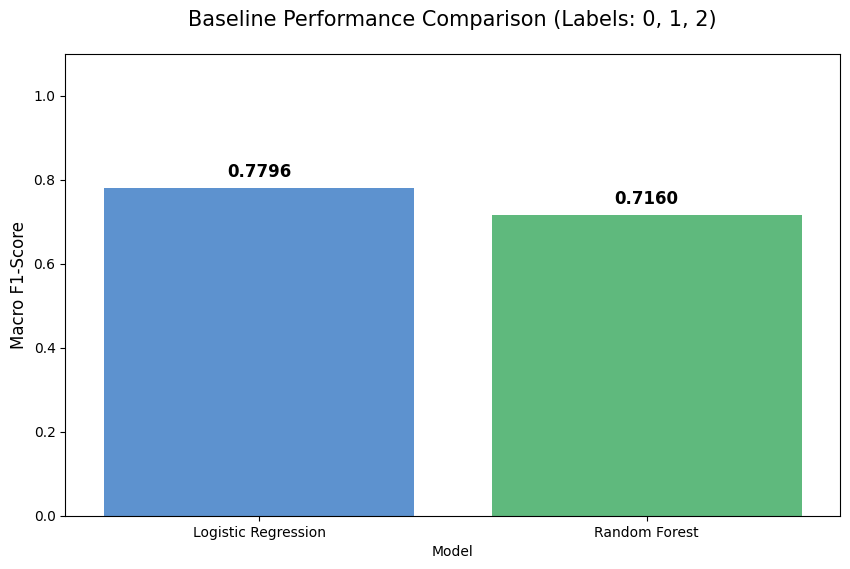


Đã lưu biểu đồ so sánh mô hình vào Drive: /content/drive/MyDrive/ML-ABSA/eda_charts/5_baseline_optimized.png
Save model !
Đã lưu TF-IDF Vectorizer tại: /content/drive/MyDrive/ML-ABSA/baseline_tfidf_vectorizer.joblib
Đã lưu Logistic Regression tại: /content/drive/MyDrive/ML-ABSA/baseline_logistic_regression.joblib
Đã lưu Random Forest tại: /content/drive/MyDrive/ML-ABSA/baseline_random_forest.joblib


In [ ]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from google.colab import drive
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.base import clone
import joblib

def run_baseline_optimized():
    print("="*60)
    print("BẮT ĐẦU CHẠY THÍ NGHIỆM BASELINE")
    print("="*60)

    train_path = os.path.join(PROJECT_DIR, 'train.csv')
    test_path = os.path.join(PROJECT_DIR, 'test.csv')

    if not os.path.exists(train_path):
        print(f"Không tìm thấy file tại: {train_path}")
        return

    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)

    categories = ['Room_Facilities', 'Service_Staff', 'Location', 'Food_Beverage', 'Price_Value', 'General']

    X_train = train_df['text'].fillna('').astype(str)
    X_test = test_df['text'].fillna('').astype(str)

    print("\nĐang tạo ma trận TF-IDF...")

    # Tăng ngram lên 3 để bắt các cụm từ phức tạp trong review khách sạn
    vectorizer = TfidfVectorizer(max_features=8000, ngram_range=(1, 3), min_df=2)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # Sử dụng Balanced để xử lý Imbalance
    base_models = {
        "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs', random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=150, class_weight='balanced', n_jobs=-1, random_state=42)
    }

    overall_results = []

    for model_name, base_model in base_models.items():
        print(f"\nModel: {model_name}")
        start_time = time.time()
        f1_per_category = []

        for cat in tqdm(categories, desc=f"Training {model_name}"):
            model = clone(base_model)

            # 0: None, 1: Neg, 2: Pos
            y_train = train_df[cat]
            y_test = test_df[cat]

            model.fit(X_train_tfidf, y_train)
            y_pred = model.predict(X_test_tfidf)

            # Macro F1 tính trung bình cho cả 3 lớp (0, 1, 2)
            score = f1_score(y_test, y_pred, average='macro')
            f1_per_category.append(score)

        avg_f1 = np.mean(f1_per_category)
        elapsed = time.time() - start_time

        overall_results.append({
            'Model': model_name,
            'Avg_F1': avg_f1,
            'Time': elapsed
        })
        print(f"F1 Trung bình: {avg_f1:.4f}")
        print(f"================================")


    res_df = pd.DataFrame(overall_results)
    plt.figure(figsize=(10, 6))

    colors = ['#4A90E2', '#50C878']
    ax = sns.barplot(data=res_df, x='Model', y='Avg_F1', palette=colors)

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5),
                    textcoords='offset points')

    plt.title('Baseline Performance Comparison (Labels: 0, 1, 2)', fontsize=15, pad=20)
    plt.ylabel('Macro F1-Score', fontsize=12)
    plt.ylim(0, 1.1)

    output_chart_dir = os.path.join(PROJECT_DIR, 'eda_charts')
    os.makedirs(output_chart_dir, exist_ok=True)

    chart_path = os.path.join(output_chart_dir, '5_baseline_optimized.png')
    plt.savefig(chart_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\nĐã lưu biểu đồ so sánh mô hình vào Drive: {chart_path}")
    # Sửa đoạn cuối hàm của Khải như sau:
    # ... (giữ nguyên code cũ của bạn)

    # 1. Tạo một dictionary để lưu trữ các model đã train
    trained_aspect_models = {"Logistic Regression": {}, "Random Forest": {}}

    # Huấn luyện lại nhanh hoặc Khải lồng việc lưu model vào vòng lặp cũ của bạn:
    for model_name, base_model in base_models.items():
        for cat in categories:
            m = clone(base_model)
            m.fit(X_train_tfidf, train_df[cat])
            trained_aspect_models[model_name][cat] = m

    print("Save model !")
    return vectorizer, trained_aspect_models, categories

vectorizer, trained_models, categories = run_baseline_optimized()

LR_PATH = os.path.join(PROJECT_DIR, 'baseline_logistic_regression.joblib')
RF_PATH = os.path.join(PROJECT_DIR, 'baseline_random_forest.joblib')
VECTORIZER_PATH = os.path.join(PROJECT_DIR, 'baseline_tfidf_vectorizer.joblib')
joblib.dump(vectorizer, VECTORIZER_PATH)
joblib.dump(trained_models["Logistic Regression"], LR_PATH)
joblib.dump(trained_models["Random Forest"], RF_PATH)
print("="*60)
print(f"Đã lưu TF-IDF Vectorizer tại: {VECTORIZER_PATH}")
print(f"Đã lưu Logistic Regression tại: {LR_PATH}")
print(f"Đã lưu Random Forest tại: {RF_PATH}")
print("="*60)

# LSTM


In [ ]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 52.6 MB/s eta 0:00:00


In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from underthesea import word_tokenize
from sklearn.metrics import f1_score
from collections import Counter
import pickle
from tqdm.auto import tqdm

PROJECT_DIR = '/content/drive/MyDrive/ML-ABSA'
TRAIN_FILE = os.path.join(PROJECT_DIR, 'train.csv')
VAL_FILE = os.path.join(PROJECT_DIR, 'val.csv')
TEST_FILE = os.path.join(PROJECT_DIR, 'test.csv')
CATEGORIES = ['Room_Facilities', 'Price_Value', 'Service_Staff', 'Location', 'Food_Beverage', 'General']

def build_vocab(sentences, max_vocab_size=10000):
    words = []
    for sent in sentences:
        words.extend(word_tokenize(sent, format="text").split())

    common_words = Counter(words).most_common(max_vocab_size)
    vocab = {word: i + 2 for i, (word, _) in enumerate(common_words)}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab

def text_to_sequence(text, vocab, max_len=128):
    tokens = word_tokenize(text, format="text").split()
    sequence = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    if len(sequence) < max_len:
        sequence += [vocab["<PAD>"]] * (max_len - len(sequence))
    else:
        sequence = sequence[:max_len]
    return sequence

class ABSADataset(Dataset):
    def __init__(self, path, vocab):
        df = pd.read_csv(path)
        self.texts = [text_to_sequence(t, vocab) for t in df['text']]

        labels = []
        for cat in CATEGORIES:
            neg = (df[cat] == 1).astype(float)
            pos = (df[cat] == 2).astype(float)
            labels.append(neg)
            labels.append(pos)
        self.labels = np.array(labels).T.tolist()

    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        return torch.tensor(self.texts[idx]), torch.tensor(self.labels[idx])

class LSTM_ABSA(nn.Module):
    def __init__(self, vocab_size, emb_dim, hid_dim, output_dim, n_layers, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.lstm = nn.LSTM(emb_dim, hid_dim, num_layers=n_layers,
                           bidirectional=True, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hid_dim * 2, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, text):
        embedded = self.dropout(self.embedding(text))
        output, (hidden, cell) = self.lstm(embedded)
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1))
        return self.fc(hidden)
def train():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    train_df = pd.read_csv(TRAIN_FILE)
    vocab = build_vocab(train_df['text'])

    train_ds = ABSADataset(TRAIN_FILE, vocab)
    val_ds = ABSADataset(VAL_FILE, vocab)
    test_ds = ABSADataset(TEST_FILE, vocab)

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64)
    test_loader = DataLoader(test_ds, batch_size=64)

    model = LSTM_ABSA(len(vocab), 300, 128, 12, 2, 0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    print("Bắt đầu huấn luyện LSTM...")
    for epoch in range(10):
        model.train()
        total_loss = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/10 [Train]", unit="batch")
        for texts, labels in train_bar:
            texts, labels = texts.to(device), labels.to(device)
            optimizer.zero_grad()
            output = model(texts)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            train_bar.set_postfix(loss=f"{loss.item():.4f}")

        model.eval()
        all_preds, all_labels = [], []

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/10 [Val]", unit="batch", leave=False)
        with torch.no_grad():
            for texts, labels in val_bar:
                output = model(texts.to(device))
                preds = torch.sigmoid(output).cpu().numpy() > 0.5
                all_preds.extend(preds)
                all_labels.extend(labels.numpy())

        f1 = f1_score(all_labels, all_preds, average='macro')
        print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f} | Val F1 = {f1:.4f}")

    print("\nĐÁNH GIÁ TRÊN TẬP TEST...")
    model.eval()
    test_preds, test_labels = [], []
    with torch.no_grad():
        for texts, labels in test_loader:
            output = model(texts.to(device))
            preds = torch.sigmoid(output).cpu().numpy() > 0.5
            test_preds.extend(preds)
            test_labels.extend(labels.numpy())

    final_f1 = f1_score(test_labels, test_preds, average='macro')
    print(f"FINAL TEST F1-SCORE (LSTM): {final_f1:.4f}")



    MODEL_SAVE_PATH = os.path.join(PROJECT_DIR, 'lstm_absa_model.pt')
    torch.save(model.state_dict(), MODEL_SAVE_PATH)
    print(f"Đã lưu model thành công tại: {MODEL_SAVE_PATH}")

    VOCAB_SAVE_PATH = os.path.join(PROJECT_DIR, 'vocab.pkl')
    with open(VOCAB_SAVE_PATH, 'wb') as f:
        pickle.dump(vocab, f)
    print(f"Đã lưu từ điển tại: {VOCAB_SAVE_PATH}")

train()

Bắt đầu huấn luyện LSTM...


Epoch 1/10 [Train]:   0%|          | 0/122 [00:00<?, ?batch/s]

Epoch 1/10 [Val]:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 1: Loss = 0.3765 | Val F1 = 0.2167


Epoch 2/10 [Train]:   0%|          | 0/122 [00:00<?, ?batch/s]

...

Epoch 9/10 [Val]:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 9: Loss = 0.1969 | Val F1 = 0.6266


Epoch 10/10 [Train]:   0%|          | 0/122 [00:00<?, ?batch/s]

Epoch 10/10 [Val]:   0%|          | 0/16 [00:00<?, ?batch/s]

Epoch 10: Loss = 0.1894 | Val F1 = 0.6309

ĐÁNH GIÁ TRÊN TẬP TEST...
FINAL TEST F1-SCORE (LSTM): 0.6465
Đã lưu model thành công tại: /content/drive/MyDrive/ML-ABSA/lstm_absa_model.pt
Đã lưu từ điển tại: /content/drive/MyDrive/ML-ABSA/vocab.pkl


# CNN LSTM


In [ ]:
!pip install -q scikit-learn pandas numpy torch

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import pickle
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import f1_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tqdm.auto import tqdm

PROJECT_DIR = '/content/drive/MyDrive/ML-ABSA'
MAX_WORDS = 10000
MAX_LEN = 128
EMBED_DIM = 128
NUM_FILTERS = 100
KERNEL_SIZE = 3
HIDDEN_DIM = 128
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-3

def load_data_cnn_lstm():
    train_df = pd.read_csv(os.path.join(PROJECT_DIR, 'train.csv')).fillna('')
    val_df = pd.read_csv(os.path.join(PROJECT_DIR, 'val.csv')).fillna('')
    test_df = pd.read_csv(os.path.join(PROJECT_DIR, 'test.csv')).fillna('')

    categories = ['Room_Facilities', 'Service_Staff', 'Location', 'Food_Beverage', 'Price_Value', 'General']

    def get_labels(df):
        label_list = []
        for cat in categories:
            df[f'{cat}_Neg'] = (df[cat] == 1).astype(float)
            df[f'{cat}_Pos'] = (df[cat] == 2).astype(float)
            label_list.extend([f'{cat}_Neg', f'{cat}_Pos'])
        return df[label_list].values, label_list

    y_train, label_names = get_labels(train_df)
    y_val, _ = get_labels(val_df)
    y_test, _ = get_labels(test_df)

    tokenizer = Tokenizer(num_words=MAX_WORDS, lower=True)
    tokenizer.fit_on_texts(train_df['text'])

    X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['text']), maxlen=MAX_LEN)
    X_val = pad_sequences(tokenizer.texts_to_sequences(val_df['text']), maxlen=MAX_LEN)
    X_test = pad_sequences(tokenizer.texts_to_sequences(test_df['text']), maxlen=MAX_LEN)

    return X_train, y_train, X_val, y_val, X_test, y_test, len(tokenizer.word_index) + 1, label_names, tokenizer

class ABSADataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class CNN_LSTM_Model(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, kernel_size, hidden_dim, num_labels):
        super(CNN_LSTM_Model, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv = nn.Conv1d(embed_dim, num_filters, kernel_size)
        self.lstm = nn.LSTM(num_filters, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, num_labels)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.embedding(x).permute(0, 2, 1)
        x = F.relu(self.conv(x)).permute(0, 2, 1)
        _, (h, _) = self.lstm(x)
        x = torch.cat((h[-2,:,:], h[-1,:,:]), dim=1)
        return self.fc(self.dropout(x))

X_train, y_train, X_val, y_val, X_test, y_test, vocab_sz, label_names, tokenizer = load_data_cnn_lstm()

train_loader = DataLoader(ABSADataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(ABSADataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(ABSADataset(X_test, y_test), batch_size=BATCH_SIZE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_LSTM_Model(vocab_sz, EMBED_DIM, NUM_FILTERS, KERNEL_SIZE, HIDDEN_DIM, len(label_names)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

print(f"🚀 Bắt đầu huấn luyện CNN-LSTM trên {device}...")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    # Cập nhật thanh tiến trình Train
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")
    for texts, labels in train_bar:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    # Validation
    model.eval()
    all_preds, all_labels = [], []
    val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Val]", unit="batch", leave=False)
    with torch.no_grad():
        for texts, labels in val_bar:
            outputs = torch.sigmoid(model(texts.to(device))).cpu().numpy()
            all_preds.extend((outputs > 0.5).astype(int))
            all_labels.extend(labels.numpy())

    val_f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"✅ Kết thúc Epoch {epoch+1}: Avg Loss: {train_loss/len(train_loader):.4f} - Val F1: {val_f1:.4f}")

# --- 4. KẾT QUẢ TẬP TEST ---
print("\n🔍 Đánh giá trên tập TEST...")
model.eval()
test_preds, test_labels = [], []
with torch.no_grad():
    for texts, labels in tqdm(test_loader, desc="Testing"):
        outputs = torch.sigmoid(model(texts.to(device))).cpu().numpy()
        test_preds.extend((outputs > 0.5).astype(int))
        test_labels.extend(labels.numpy())

final_f1 = f1_score(test_labels, test_preds, average='macro')
print(f"🔥 CNN-LSTM TEST F1 MACRO: {final_f1:.4f}")

# --- 5. LƯU MÔ HÌNH & TOKENIZER ---
print("\n💾 Đang lưu tài nguyên...")

# Lưu trọng số PyTorch
MODEL_SAVE_PATH = os.path.join(PROJECT_DIR, 'cnn_lstm_absa_model.pt')
torch.save(model.state_dict(), MODEL_SAVE_PATH)

# Lưu Tokenizer Keras (Rất quan trọng cho Interface)
TOKENIZER_SAVE_PATH = os.path.join(PROJECT_DIR, 'cnn_lstm_tokenizer.pkl')
with open(TOKENIZER_SAVE_PATH, 'wb') as f:
    pickle.dump(tokenizer, f)

# Lưu danh sách nhãn
LABEL_SAVE_PATH = os.path.join(PROJECT_DIR, 'cnn_lstm_labels.pkl')
with open(LABEL_SAVE_PATH, 'wb') as f:
    pickle.dump(label_names, f)

print(f"✅ Hoàn tất! Model, Tokenizer và Labels đã được lưu tại {PROJECT_DIR}")

🚀 Bắt đầu huấn luyện CNN-LSTM trên cpu...


Epoch 1/10 [Train]:   0%|          | 0/243 [00:00<?, ?batch/s]

Epoch 1/10 [Val]:   0%|          | 0/31 [00:00<?, ?batch/s]

✅ Kết thúc Epoch 1: Avg Loss: 0.3584 - Val F1: 0.1635


Epoch 2/10 [Train]:   0%|          | 0/243 [00:00<?, ?batch/s]

...

Epoch 10/10 [Train]:   0%|          | 0/243 [00:00<?, ?batch/s]

Epoch 10/10 [Val]:   0%|          | 0/31 [00:00<?, ?batch/s]

✅ Kết thúc Epoch 10: Avg Loss: 0.1224 - Val F1: 0.6725

🔍 Đánh giá trên tập TEST...


Testing:   0%|          | 0/31 [00:00<?, ?it/s]

🔥 CNN-LSTM TEST F1 MACRO: 0.6931

💾 Đang lưu tài nguyên...
✅ Hoàn tất! Model, Tokenizer và Labels đã được lưu tại /content/drive/MyDrive/ML-ABSA


# PhoBERT


In [ ]:
!pip install underthesea transformers datasets

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import gc
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import f1_score
from underthesea import word_tokenize

PROJECT_DIR = '/content/drive/MyDrive/ML-ABSA'
TRAIN_FILE = os.path.join(PROJECT_DIR, 'train.csv')
VAL_FILE = os.path.join(PROJECT_DIR, 'val.csv')
TEST_FILE = os.path.join(PROJECT_DIR, 'test.csv')
CHECKPOINT_DIR = os.path.join(PROJECT_DIR, 'phobert_checkpoints')
FINAL_MODEL_PATH = os.path.join(PROJECT_DIR, "phobert_final_model")

CATEGORIES = ['Room_Facilities', 'Service_Staff', 'Location', 'Food_Beverage', 'Price_Value', 'General']

def prepare_phobert_data():
    print(" Đang chuẩn bị dữ liệu cho PhoBERT...")

    def process_df(path):
        df = pd.read_csv(path).fillna('')
        df['text'] = df['text'].apply(lambda x: word_tokenize(str(x), format="text"))

        for cat in CATEGORIES:
            df[f'{cat}_Neg'] = (df[cat] == 1).astype(float)
            df[f'{cat}_Pos'] = (df[cat] == 2).astype(float)

        label_cols = []
        for cat in CATEGORIES:
            label_cols.extend([f'{cat}_Neg', f'{cat}_Pos'])

        df['labels'] = df[label_cols].values.tolist()
        return df[['text', 'labels']], label_cols

    train_df, label_cols = process_df(TRAIN_FILE)
    val_df, _ = process_df(VAL_FILE)
    test_df, _ = process_df(TEST_FILE)

    dataset = DatasetDict({
        'train': Dataset.from_pandas(train_df),
        'validation': Dataset.from_pandas(val_df),
        'test': Dataset.from_pandas(test_df)
    })
    return dataset, label_cols

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))
    predictions = (probs > 0.5).astype(float)
    f1 = f1_score(labels, predictions, average='macro')
    return {"f1_macro": f1}

def main():
    gc.collect()
    torch.cuda.empty_cache()

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Thiết bị sử dụng: {device.upper()}")

    dataset, label_cols = prepare_phobert_data()
    num_labels = len(label_cols)

    tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)

    def tokenize_func(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

    tokenized_datasets = dataset.map(tokenize_func, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        "vinai/phobert-base",
        num_labels=num_labels,
        problem_type="multi_label_classification"
    ).to(device)

    training_args = TrainingArguments(
        output_dir=CHECKPOINT_DIR,
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=3e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        save_total_limit=1,
        logging_steps=50,
        fp16=True if torch.cuda.is_available() else False,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        compute_metrics=compute_metrics
    )

    print("\nBẮT ĐẦU FINE-TUNING PHO-BERT...")
    resume_point = True if os.path.exists(CHECKPOINT_DIR) and os.listdir(CHECKPOINT_DIR) else False
    trainer.train(resume_from_checkpoint=resume_point)

if __name__ == "__main__":
    main()

Thiết bị sử dụng: CUDA
 Đang chuẩn bị dữ liệu cho PhoBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Map:   0%|          | 0/7752 [00:00<?, ? examples/s]

Map:   0%|          | 0/969 [00:00<?, ? examples/s]

Map:   0%|          | 0/969 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

# BARTpho

In [ ]:
!pip install transformers[torch] datasets pyarrow underthesea

In [ ]:
import pandas as pd
import os
import torch
import pickle
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer
from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/ML-ABSA'
MODEL_CHECKPOINT = "vinai/bartpho-syllable"
CATEGORIES = ['Room_Facilities', 'Service_Staff', 'Location', 'Food_Beverage', 'Price_Value', 'General']

def convert_to_text_format(path):
    df = pd.read_csv(path).fillna('')
    data_list = []

    for _, row in df.iterrows():
        input_text = row['text']
        targets = []
        for cat in CATEGORIES:
            val = row[cat]
            if val == 1: targets.append(f"{cat}:Negative")
            elif val == 2: targets.append(f"{cat}:Positive")

        target_text = ", ".join(targets) if targets else "None"
        data_list.append({"input_text": input_text, "target_text": target_text})

    return Dataset.from_list(data_list)

train_dataset = convert_to_text_format(os.path.join(PROJECT_DIR, 'train.csv'))
val_dataset = convert_to_text_format(os.path.join(PROJECT_DIR, 'val.csv'))

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def preprocess_function(examples):
    model_inputs = tokenizer(examples["input_text"], max_length=128, truncation=True, padding="max_length")
    labels = tokenizer(text_target=examples["target_text"], max_length=64, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_val = val_dataset.map(preprocess_function, batched=True)

model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_CHECKPOINT)
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

training_args = Seq2SeqTrainingArguments(
    output_dir="./bartpho_absa_checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=5,
    predict_with_generate=True,
    fp16=True,
    push_to_hub=False,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    tokenizer=tokenizer,
    data_collator=data_collator,
)

print("Đang bắt đầu huấn luyện BARTpho...")
trainer.train()

SAVE_PATH = os.path.join(PROJECT_DIR, 'best_bartpho_model')
trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f" Đã lưu BARTpho tại: {SAVE_PATH}")